In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import torch
import pandas as pd
import numpy as np

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_dataset import (
    FeatureDataset
)

from src.dataset.feature_loader import (
    build_dataloader
)

In [3]:
# --------------------------------------------------
# Configs
# --------------------------------------------------

data_cfg = load_yaml(

    PROJECT_ROOT
    / "configs"
    / "data_config.yaml"
)

train_cfg = load_yaml(

    PROJECT_ROOT
    / "configs"
    / "train_config.yaml"
)

model_cfg = load_yaml(

    PROJECT_ROOT
    / "configs"
    / "model_config.yaml"
)

print(data_cfg.keys())
print(train_cfg.keys())
print(model_cfg.keys())

dict_keys(['project_name', 'audio_extensions', 'dataset', 'outputs', 'audio', 'fragmentation'])
dict_keys(['training', 'optimizer', 'scheduler', 'gradient', 'mixed_precision', 'checkpoint', 'early_stopping', 'stage_training'])
dict_keys(['factorized_model', 'betas', 'model', 'losses'])


## **Inventory Inspection**

In [4]:
inventory = pd.read_csv(

    PROJECT_ROOT
    / "data"
    / "metadata"
    / "feature_inventory_v2.csv"
)

print(

    "Total Fragments:",
    len(inventory)
)

inventory.head()

Total Fragments: 311


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,...,modgd_shape,logmel_shape,mr_mag_256_shape,mr_phase_256_shape,mr_mag_512_shape,mr_phase_512_shape,mr_mag_1024_shape,mr_phase_1024_shape,available_features,sample_rate
0,s1,clean,train,s1_clean_01.wav,0,0,0,10752,13056,0.672,...,"[513, 37]","[80, 37]","[129, 73]","[129, 73]","[257, 37]","[257, 37]","[513, 19]","[513, 19]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,...,"[513, 69]","[80, 69]","[129, 137]","[129, 137]","[257, 69]","[257, 69]","[513, 35]","[513, 35]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,...,"[513, 55]","[80, 55]","[129, 109]","[129, 109]","[257, 55]","[257, 55]","[513, 28]","[513, 28]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,...,"[513, 27]","[80, 27]","[129, 53]","[129, 53]","[257, 27]","[257, 27]","[513, 14]","[513, 14]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,...,"[513, 25]","[80, 25]","[129, 49]","[129, 49]","[257, 25]","[257, 25]","[513, 13]","[513, 13]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000


In [5]:
inventory["split"].value_counts()

split
train    290
test      21
Name: count, dtype: int64

In [6]:
inventory["condition"].value_counts()

condition
noisy    182
clean    129
Name: count, dtype: int64

In [7]:
inventory.groupby(

    "speaker"

).size().sort_values(
    ascending=False
).head(20)

speaker
s2    170
s1    141
dtype: int64

## **Dataset Inspection**

In [8]:
dataset = FeatureDataset(

    inventory_csv=

        PROJECT_ROOT
        / "data"
        / "metadata"
        / "feature_inventory_v2.csv",

    split="train"
)

print(

    "Dataset Size:",
    len(dataset)
)

Dataset Size: 290


In [9]:
sample = dataset[0]

sample.keys()

dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'speaker', 'condition', 'split', 'fragment_id', 'source_file', 'relative_position'])

In [10]:
row = inventory.iloc[0]

print(row["tensor_file"])

d:\IITG\Projects\audio_factor_disentanglement_v2\data\fragments\speaker_1\s1_clean_01\padded\fragment_000.npy


In [12]:
for k,v in sample.items():

    if torch.is_tensor(v):

        print(
            k,
            v.shape
        )

logmel torch.Size([80, 37])
mr_mag_256 torch.Size([129, 73])
mr_mag_512 torch.Size([257, 37])
mr_mag_1024 torch.Size([513, 19])
magnitude torch.Size([513, 37])
if torch.Size([513, 37])
modgd torch.Size([513, 37])
phase_sin torch.Size([513, 37])
phase_cos torch.Size([513, 37])


## **Feature Shape Verification**

In [14]:
expected_shapes = {

    "logmel":80,

    "mr_mag_256":129,

    "mr_mag_512":257,

    "mr_mag_1024":513,

    "magnitude":513,

    "if":513,

    "modgd":513,

    "phase_sin":513,

    "phase_cos":513
}

In [15]:
for feature_name,freq_bins in expected_shapes.items():

    tensor = sample[feature_name]

    print(
        feature_name,
        tensor.shape
    )

    assert (

        tensor.shape[0]
        ==
        freq_bins

    ), f"{feature_name} mismatch"

logmel torch.Size([80, 37])
mr_mag_256 torch.Size([129, 73])
mr_mag_512 torch.Size([257, 37])
mr_mag_1024 torch.Size([513, 19])
magnitude torch.Size([513, 37])
if torch.Size([513, 37])
modgd torch.Size([513, 37])
phase_sin torch.Size([513, 37])
phase_cos torch.Size([513, 37])


## **Time Dimension Statistics**

In [16]:
time_lengths = []

for idx in range(

    min(
        1000,
        len(dataset)
    )
):

    x = dataset[idx]

    time_lengths.append(

        x["magnitude"].shape[-1]
    )

In [17]:
print(

    "Min:",
    np.min(time_lengths)
)

print(

    "Mean:",
    np.mean(time_lengths)
)

print(

    "Max:",
    np.max(time_lengths)
)

Min: 21
Mean: 52.61379310344827
Max: 133


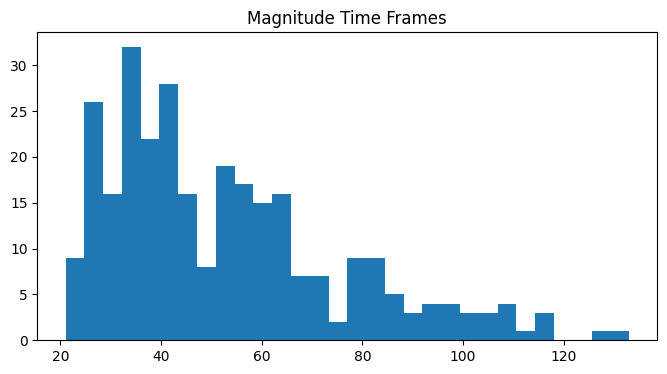

In [18]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,4)
)

plt.hist(
    time_lengths,
    bins=30
)

plt.title(
    "Magnitude Time Frames"
)

plt.show()

## **DataLoader**

In [19]:
train_loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

val_loader = build_dataloader(

    PROJECT_ROOT,

    split="val"
)

print("Loaders Built")

Loaders Built


In [20]:
batch = next(

    iter(
        train_loader
    )
)

batch.keys()

c:\Users\Dell\.conda\envs\betavae\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'speaker', 'condition', 'split'])

In [21]:
for k,v in batch.items():

    if isinstance(
        v,
        torch.Tensor
    ):

        print(
            k,
            v.shape
        )

logmel torch.Size([16, 80, 91])
mr_mag_256 torch.Size([16, 129, 181])
mr_mag_512 torch.Size([16, 257, 91])
mr_mag_1024 torch.Size([16, 513, 46])
magnitude torch.Size([16, 513, 91])
if torch.Size([16, 513, 91])
modgd torch.Size([16, 513, 91])
phase_sin torch.Size([16, 513, 91])
phase_cos torch.Size([16, 513, 91])


## **Numerical Stability**

In [22]:
for feature_name in [

    "logmel",

    "mr_mag_256",

    "mr_mag_512",

    "mr_mag_1024",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",

    "phase_cos"
]:

    x = batch[
        feature_name
    ]

    print()

    print(feature_name)

    print(

        "Min:",
        x.min().item()
    )

    print(

        "Max:",
        x.max().item()
    )

    print(

        "NaN:",
        torch.isnan(
            x
        ).any().item()
    )

    print(

        "Inf:",
        torch.isinf(
            x
        ).any().item()
    )


logmel
Min: 0.0
Max: 1.0
NaN: False
Inf: False

mr_mag_256
Min: 0.0
Max: 1.0
NaN: False
Inf: False

mr_mag_512
Min: 0.0
Max: 1.0
NaN: False
Inf: False

mr_mag_1024
Min: 0.0
Max: 1.0
NaN: False
Inf: False

magnitude
Min: 0.0
Max: 1.0
NaN: False
Inf: False

if
Min: -2.0376882553100586
Max: 2.030400037765503
NaN: False
Inf: False

modgd
Min: -1.0
Max: 1.0
NaN: False
Inf: False

phase_sin
Min: -1.0
Max: 1.0
NaN: False
Inf: False

phase_cos
Min: -1.0
Max: 1.0
NaN: False
Inf: False


## **Visual Inspection**

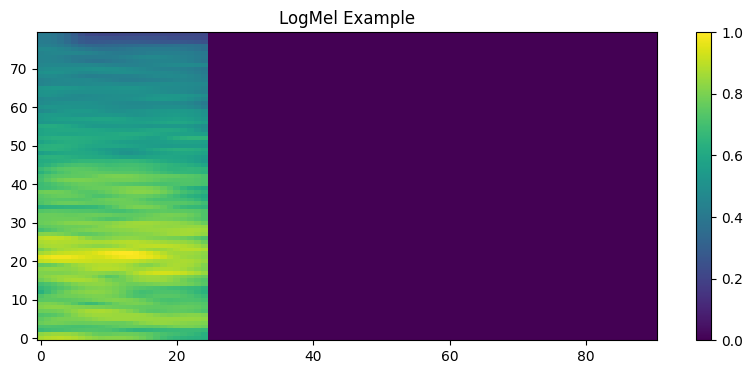

In [23]:
import matplotlib.pyplot as plt

feature = batch[
    "logmel"
][0].numpy()

plt.figure(
    figsize=(10,4)
)

plt.imshow(

    feature,

    aspect="auto",

    origin="lower"
)

plt.title(
    "LogMel Example"
)

plt.colorbar()

plt.show()

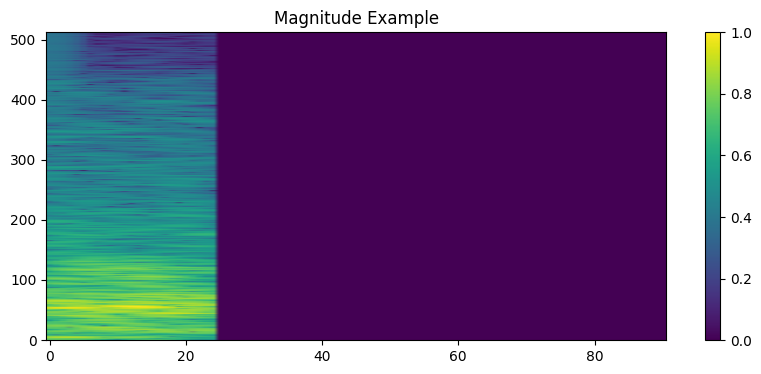

In [24]:
feature = batch[
    "magnitude"
][0].numpy()

plt.figure(
    figsize=(10,4)
)

plt.imshow(

    feature,

    aspect="auto",

    origin="lower"
)

plt.title(
    "Magnitude Example"
)

plt.colorbar()

plt.show()

## **06B Compatibility**

In [25]:
from src.models.factorized.feature_group_manager import (
    FeatureGroupManager
)

manager = FeatureGroupManager()

In [28]:
groups = manager.build_groups(
    batch
)

groups.keys()

dict_keys(['content', 'speaker', 'environment', 'excitation', 'fidelity'])

In [29]:
for group_name in groups:

    print()

    print(
        "=" * 60
    )

    print(
        group_name.upper()
    )

    print(
        "=" * 60
    )

    group = groups[
        group_name
    ]

    if isinstance(
        group,
        dict
    ):

        for k,v in group.items():

            print(
                k,
                v.shape
            )

    else:

        print(
            group.shape
        )


CONTENT
logmel torch.Size([16, 80, 91])
mr_mag_256 torch.Size([16, 129, 181])
if torch.Size([16, 513, 91])

SPEAKER
mr_mag_512 torch.Size([16, 257, 91])
mr_mag_256 torch.Size([16, 129, 181])
logmel torch.Size([16, 80, 91])

ENVIRONMENT
magnitude torch.Size([16, 513, 91])
mr_mag_1024 torch.Size([16, 513, 46])
if torch.Size([16, 513, 91])

EXCITATION
modgd torch.Size([16, 513, 91])

FIDELITY
phase_sin torch.Size([16, 513, 91])
phase_cos torch.Size([16, 513, 91])
mr_mag_512 torch.Size([16, 257, 91])
mr_mag_1024 torch.Size([16, 513, 46])
magnitude torch.Size([16, 513, 91])
modgd torch.Size([16, 513, 91])


In [30]:
device = (

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print(device)

cpu


In [31]:
for feature_name in [

    "logmel",

    "mr_mag_256",

    "mr_mag_512",

    "mr_mag_1024",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",

    "phase_cos"
]:

    batch[feature_name] = (

        batch[feature_name]
        .to(device)
    )

print(
    "GPU Transfer Success"
)

GPU Transfer Success


In [32]:
logmel_lengths = []

for i in range(len(dataset)):

    sample = dataset[i]

    logmel_lengths.append(
        sample["logmel"].shape[-1]
    )

logmel_lengths = np.array(
    logmel_lengths
)

print(
    "Min:",
    logmel_lengths.min()
)

print(
    "Mean:",
    logmel_lengths.mean()
)

print(
    "Median:",
    np.median(logmel_lengths)
)

print(
    "95%:",
    np.percentile(
        logmel_lengths,
        95
    )
)

print(
    "Max:",
    logmel_lengths.max()
)

Min: 21
Mean: 52.61379310344827
Median: 47.0
95%: 102.10000000000002
Max: 133


In [33]:
bins = [

    (0,40),

    (40,60),

    (60,80),

    (80,100),

    (100,999)
]

for low, high in bins:

    count = (

        (
            logmel_lengths >= low
        )

        &

        (
            logmel_lengths < high
        )

    ).sum()

    print(
        f"{low:3d}-{high:3d}: {count}"
    )

  0- 40: 105
 40- 60: 98
 60- 80: 46
 80-100: 25
100-999: 16


In [34]:
current_max = (
    logmel_lengths.max()
)

padding_waste = (

    current_max
    -
    logmel_lengths
)

print(

    "Average wasted frames:",

    padding_waste.mean()
)

print(

    "Average waste ratio:",

    (
        padding_waste.mean()
        /
        current_max
    )
)

Average wasted frames: 80.38620689655173
Average waste ratio: 0.6044075706507649


In [35]:
bucket_specs = [

    (0,40),

    (40,60),

    (60,80),

    (80,100),

    (100,999)
]

total_waste = 0
total_samples = 0

for low, high in bucket_specs:

    bucket = logmel_lengths[

        (
            logmel_lengths >= low
        )

        &

        (
            logmel_lengths < high
        )
    ]

    if len(bucket) == 0:
        continue

    bucket_max = bucket.max()

    waste = (

        bucket_max
        -
        bucket
    ).sum()

    total_waste += waste

    total_samples += len(bucket)

    print(
        f"{low}-{high}"
    )

    print(
        "samples:",
        len(bucket)
    )

    print(
        "max:",
        bucket_max
    )

    print(
        "avg waste:",
        waste / len(bucket)
    )

    print()

0-40
samples: 105
max: 39
avg waste: 7.695238095238095

40-60
samples: 98
max: 59
avg waste: 9.693877551020408

60-80
samples: 46
max: 79
avg waste: 10.108695652173912

80-100
samples: 25
max: 99
avg waste: 11.16

100-999
samples: 16
max: 133
avg waste: 22.125



In [36]:
global_waste = (

    (
        logmel_lengths.max()
        -
        logmel_lengths
    )
    .sum()
)

bucket_waste = 0

for low, high in bucket_specs:

    bucket = logmel_lengths[

        (
            logmel_lengths >= low
        )

        &

        (
            logmel_lengths < high
        )
    ]

    if len(bucket) == 0:
        continue

    bucket_waste += (

        bucket.max()
        -
        bucket
    ).sum()

print(
    "Global Waste:",
    global_waste
)

print(
    "Bucket Waste:",
    bucket_waste
)

print(
    "Reduction:",
    (
        1 -
        bucket_waste
        /
        global_waste
    )
    * 100
)

Global Waste: 23312
Bucket Waste: 2856
Reduction: 87.74879890185312
